In [1]:
from pathlib import Path 
import os 
import sys
import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math

In [2]:
def manual_filtering(df_dict, 
                     bounds, 
                     columns_to_keep, 
                     celltype_fraction, 
                     margin_frac_prop,
                     margin_frac_bounds, 
                     protocol_cols):
    
    # Filtered data frame 
    df_dict_filtered = {}
    df_dict_annotated = {}
    
    # Iterate over cell types 
    for cell_type in df_dict:
        # Collect cell type dictionary and sort by proportion 
        cell_type_revert_safe_string = cell_type.replace(":", "/")
        df_ct = df_dict[cell_type].copy()
        df_ct = df_ct.sort_values(by=f"{cell_type_revert_safe_string}_prop", ascending=False)
        
        # Subset data frame 
        columns_to_keep_ct = columns_to_keep + [f"{cell_type_revert_safe_string}_prop"]
        df_ct = df_ct.loc[:, columns_to_keep_ct]
        df_ct["filtering_step"] = "pass" 

        # Filter by fraction
        idx_lower = df_ct[f"{cell_type_revert_safe_string}_prop"] < (celltype_fraction[cell_type_revert_safe_string] - celltype_fraction[cell_type_revert_safe_string] * margin_frac_prop)
        df_ct.loc[idx_lower, "filtering_step"] = "proportion_filter"

        # Oxygen and days filtering 
        idx_pass_oxygen_days = np.logical_and(df_ct["o2_[%]"]>7, 
                                              df_ct["o2_[%]"]<23)
        idx_pass_oxygen_days = np.logical_and(idx_pass_oxygen_days, 
                                              df_ct["days_of_culture"]>12)
        idx_pass_oxygen_days = np.logical_and(idx_pass_oxygen_days, 
                                              df_ct["days_of_culture"]<20)

        
        df_ct.loc[~idx_pass_oxygen_days, "filtering_step"] = "oxygen_days"

        # Bounds 
        for param in protocol_cols:
            idx_bounds = np.logical_and(df_ct[param]>=(bounds[param][0] - bounds[param][0] * margin_frac_bounds), 
                                        df_ct[param]<=(bounds[param][1] + bounds[param][1] * margin_frac_bounds))
            df_ct.loc[~idx_bounds, "filtering_step"] = f"bounds_{param}"
        
        df_dict_filtered[cell_type] = df_ct[df_ct.filtering_step=="pass"]
        df_dict_annotated[cell_type] = df_ct
        
    return df_dict_filtered, df_dict_annotated

In [3]:
import yaml

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"

with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
print(protocol_cols)

['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']


In [4]:
ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
# protocol_cols = annotation_cfg_bound["protocol_columns"]
# print(protocol_cols)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

Get real ranges 

In [5]:
real_protocol_path = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous")
real_protocol_adata = sc.read_h5ad(real_protocol_path / "unique_concentrations_adata.h5ad")

result_folder = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered"

In [6]:
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds

{'gm-csf_[ng_ml]': (0.0, 10.0),
 'tpo_[ng_ml]': (0.0, 2.5),
 'um171_[nm]': (0.0, 1120.0),
 'um729_[µm]': (0.0, 1120.0),
 'sr1_[nm]': (0.0, 750.0),
 'scf_[ng_ml]': (0.0, 50.0),
 'butyzamide_[nm]': (0.0, 100.0),
 'retinoic_acid_[µm]': (0.0, 25.0),
 'ldl_[ng_ml]': (0.0, 50.0),
 'il3_[ng_ml]': (0.0, 20.0),
 'o2_[%]': (10.0, 20.0),
 'days_of_culture': (12.0, 18.0)}

In [7]:
# celltype_fraction = {
#     "MgkPro": 0.42,
#     "HSCs": 0.21,
#     "EryPro": 0.42,
#     "GMP-Neutro/CD16-Mono": 0.17,
#     "CyclingProgenitor*": 0.30,
#     "EosBasoMastPre": 0.80,
#     "Early_Pro-B": 0.20,
#     "Pro-B": 0.20,
#     "CD14-Mono": 0.24,
#     "DCs-CD14": 0.20
# }

celltype_fraction = {
    "MgkPro": 0.20,
    "HSCs": 0.20,
    "EryPro": 0.20,
    "GMP-Neutro/CD16-Mono": 0.20,
    "CyclingProgenitor*": 0.20,
    "EosBasoMastPre": 0.20,
    "Early_Pro-B": 0.20,
    "Pro-B": 0.20,
    "CD14-Mono": 0.20,
    "DCs-CD14": 0.20
}


columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    # 'target_ct_loss_std',
    # 'ct_prop_total_variance',
    # 'exploitation_score'
]

### Loop over solutions 

In [8]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data")
paths = os.listdir(path_to_results)

In [9]:
cell_types = ["CD14-Mono",
              "CyclingProgenitor*",
              "DCs-CD14",
              "Early_Pro-B", 
              "EosBasoMastPre", 
              "EryPro",
              "GMP-Neutro:CD16-Mono",
              "HSCs",
              "MgkPro",
              "Pro-B"]

In [10]:
pure_cell_type_solution_dict = {cell_type: [] for cell_type in cell_types}

# for experiment_folder in tqdm(paths):
#     if "pure" in experiment_folder:
#         cell_type_file_paths = path_to_results / experiment_folder
#         for cell_type in os.listdir(cell_type_file_paths):
#             config_exp_folders = path_to_results / experiment_folder / cell_type
#             for config_exp_folder in os.listdir(config_exp_folders):
#                 if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
#                     try:
#                         candidate_with_uncertainty_df = pd.read_csv(config_exp_folders / config_exp_folder / "uncertainty_annotation" / "candidates_with_uncertainties.csv")
#                         pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)
#                     except:
#                         continue

for experiment_folder in tqdm(paths):
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        for cell_type in os.listdir(cell_type_file_paths):
            config_exp_folders = path_to_results / experiment_folder / cell_type
            for config_exp_folder in os.listdir(config_exp_folders):
                if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                    candidate_with_uncertainty_df = pd.read_csv(config_exp_folders / config_exp_folder / "candidates.csv")
                    candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                    pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

100%|██████████| 18/18 [02:55<00:00,  9.72s/it]


In [11]:
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key,val in pure_cell_type_solution_dict.items()
}

In [12]:
for i in pure_cell_type_solution_dict_concat["HSCs"].columns:
    print(i)

sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14-Mono_prop
CD49c-Myeloid_prop
CyclingProgenitor*_prop
DCs-CD14_prop
EarlyGMP_prop
Early_Pro-B_prop
EosBasoMastPre_prop
EosBasoMastPre_2_prop
EryPro_prop
GMP-Cycle_prop
GMP-Neutro_prop
GMP-Neutro/CD16-Mono_prop
HSCs_prop
MEP_prop
MLP_prop
MPP_prop
MgkPro_prop
Pro-B_prop
pDCs/cDCs_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_rep
cfg:annotation:scatter_obsm_key
cfg:annotation:concat_

In [13]:
filtered_df, annotated_df = manual_filtering(
    pure_cell_type_solution_dict_concat,
    bounds,
    columns_of_interest, 
    celltype_fraction,
    margin_frac_prop=0.2, 
    margin_frac_bounds=0.3, 
    protocol_cols=protocol_cols
)

In [14]:
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered CD14-Mono number of solutions: 11064
Unfiltered CD14-Mono number of solutions: 33100 

Filtered CyclingProgenitor* number of solutions: 7576
Unfiltered CyclingProgenitor* number of solutions: 27900 

Filtered DCs-CD14 number of solutions: 1545
Unfiltered DCs-CD14 number of solutions: 33100 

Filtered Early_Pro-B number of solutions: 54
Unfiltered Early_Pro-B number of solutions: 38100 

Filtered EosBasoMastPre number of solutions: 6388
Unfiltered EosBasoMastPre number of solutions: 38100 

Filtered EryPro number of solutions: 3347
Unfiltered EryPro number of solutions: 38100 

Filtered GMP-Neutro:CD16-Mono number of solutions: 5491
Unfiltered GMP-Neutro:CD16-Mono number of solutions: 25400 

Filtered HSCs number of solutions: 37
Unfiltered HSCs number of solutions: 23200 

Filtered MgkPro number of solutions: 1041
Unfiltered MgkPro number of solutions: 22900 

Filtered Pro-B number of solutions: 14
Unfiltered Pro-B number of solutions: 28100 



## Downstream

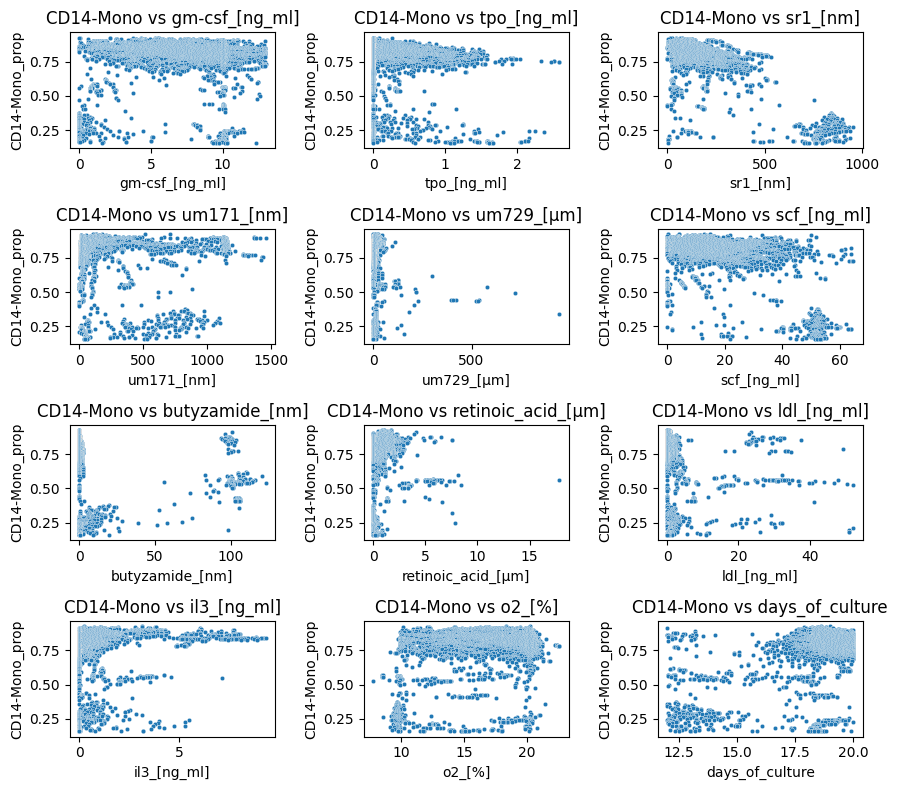

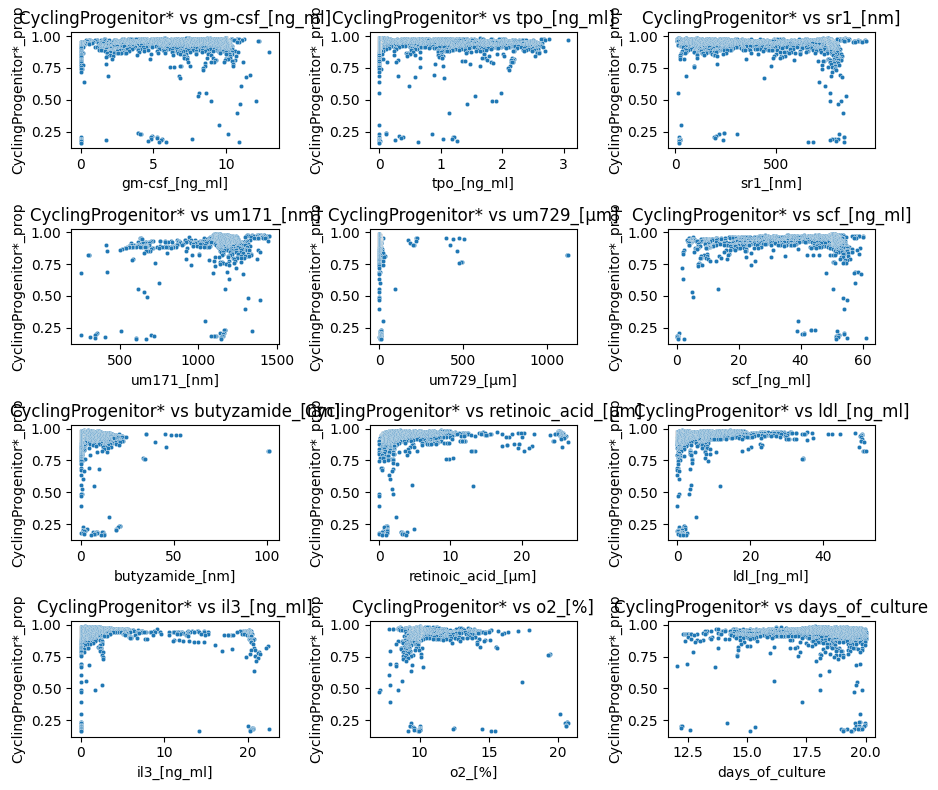

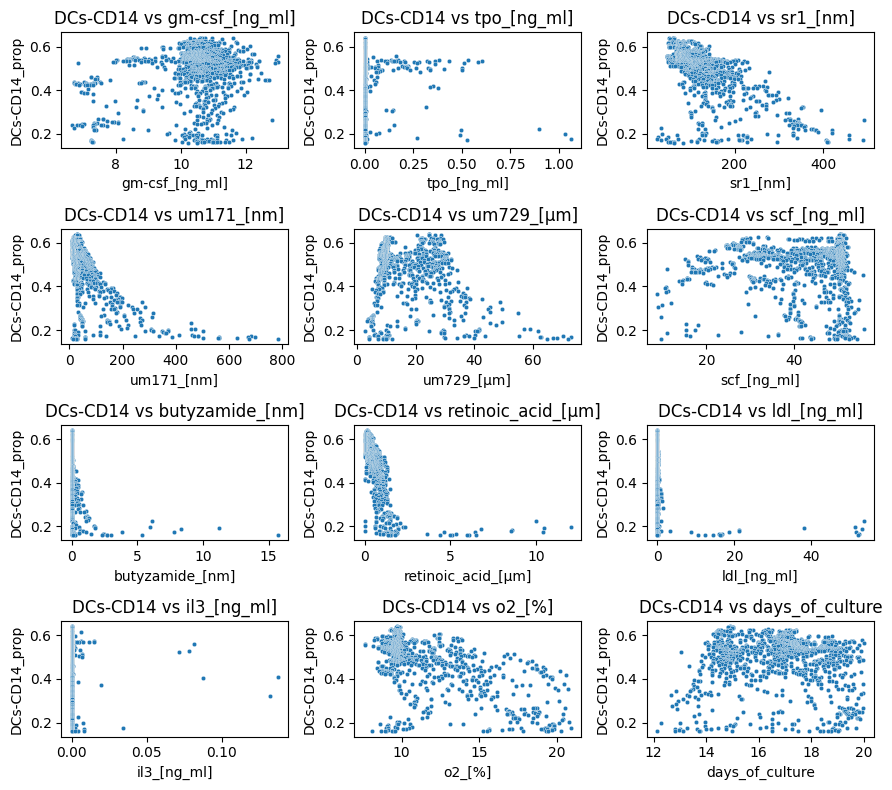

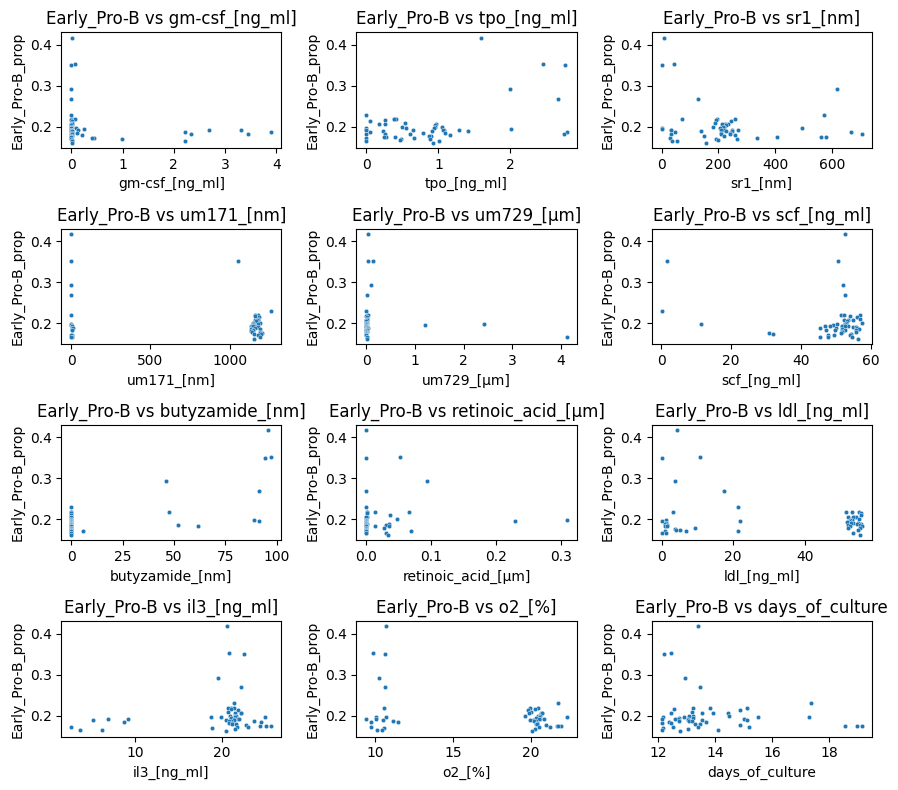

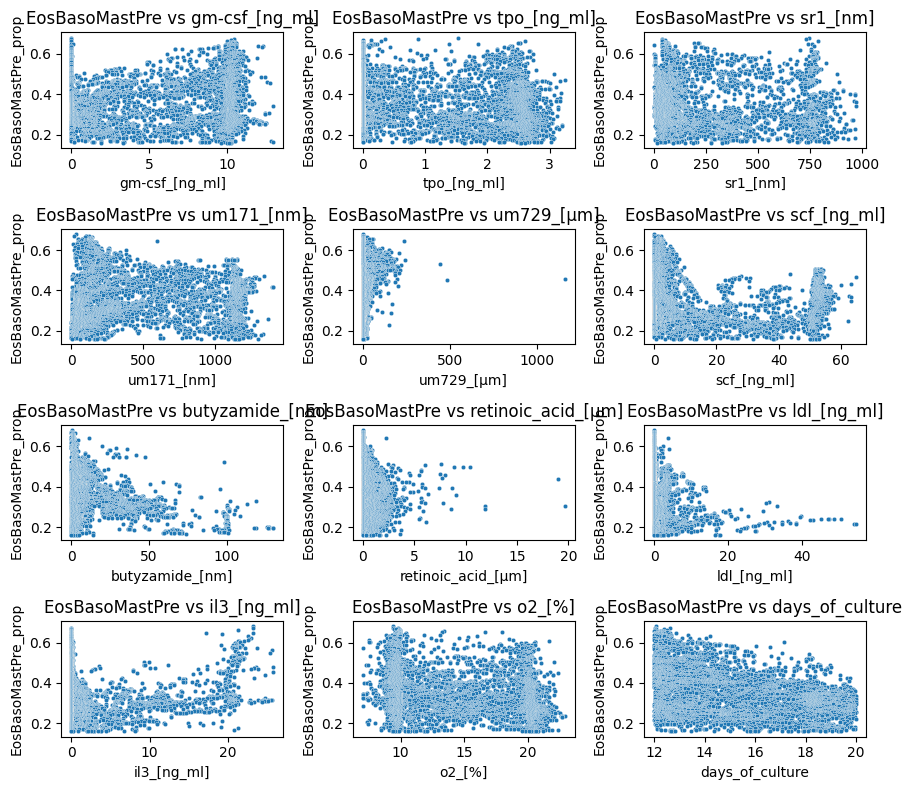

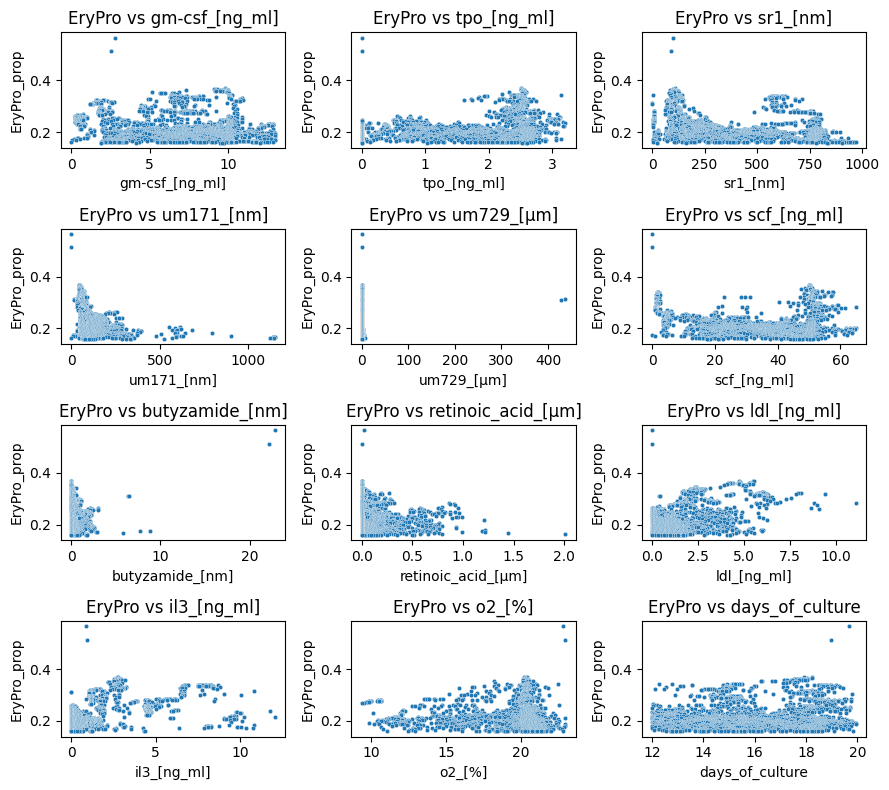

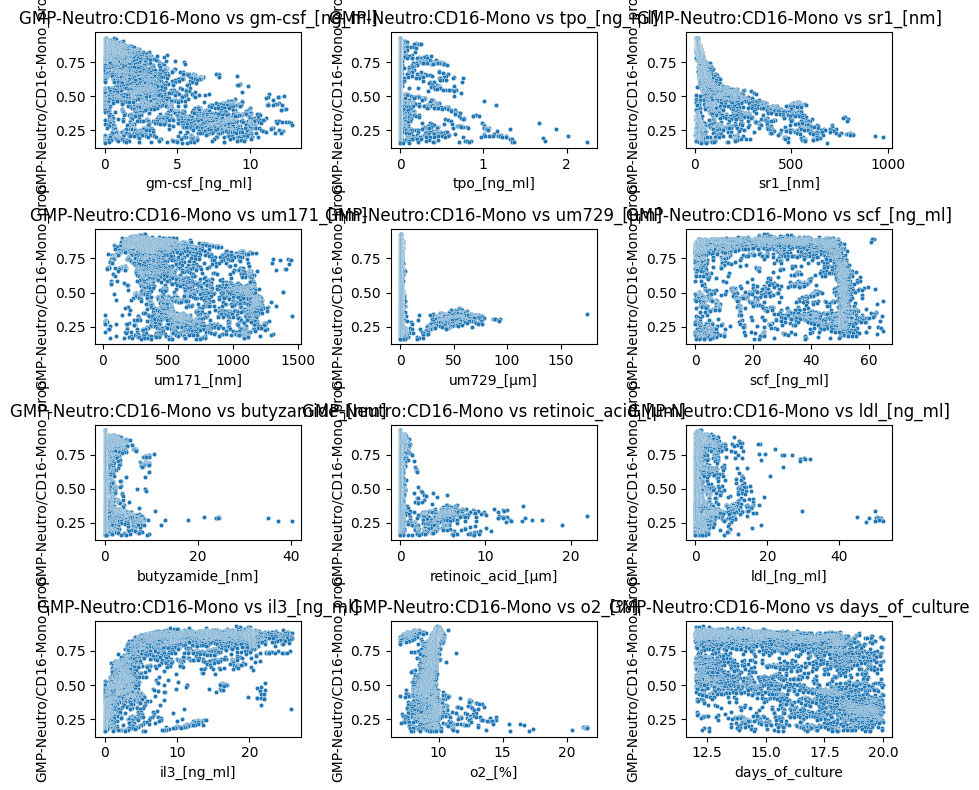

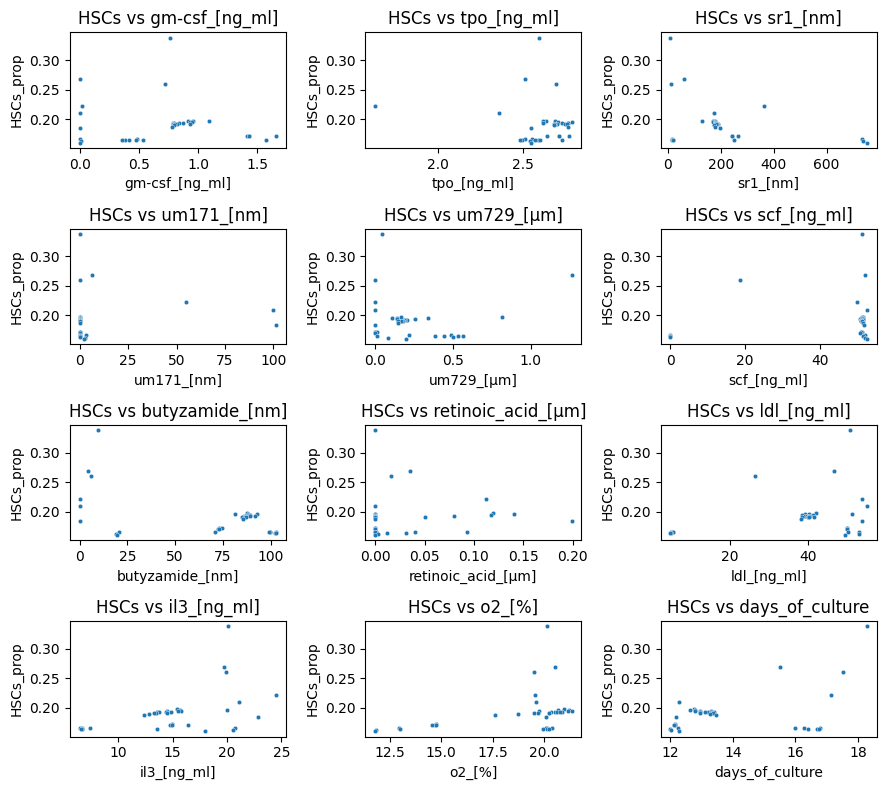

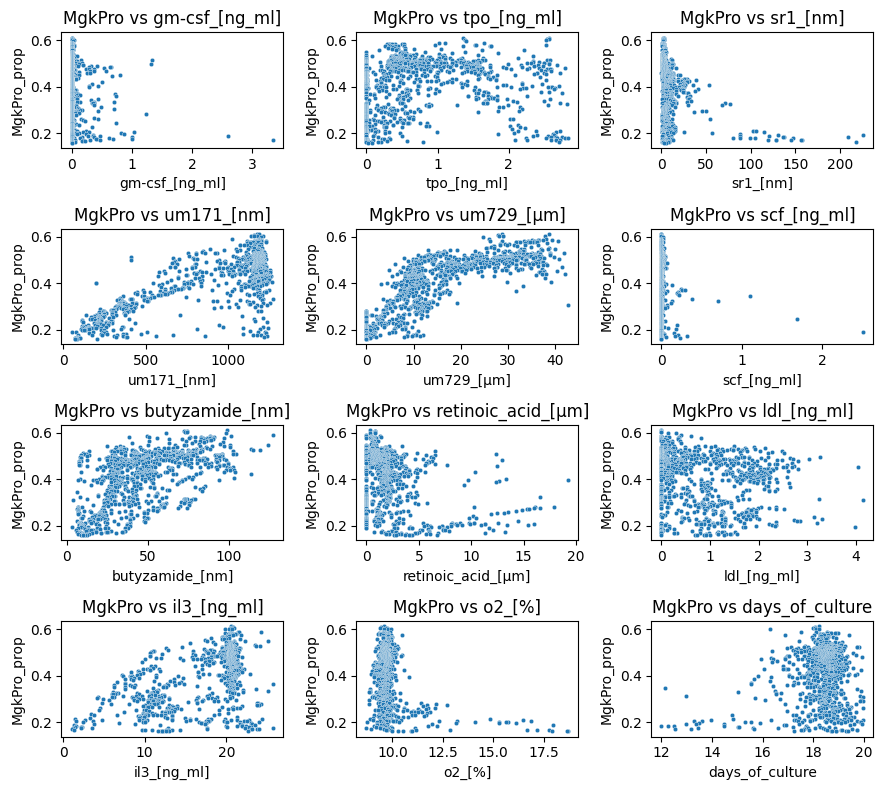

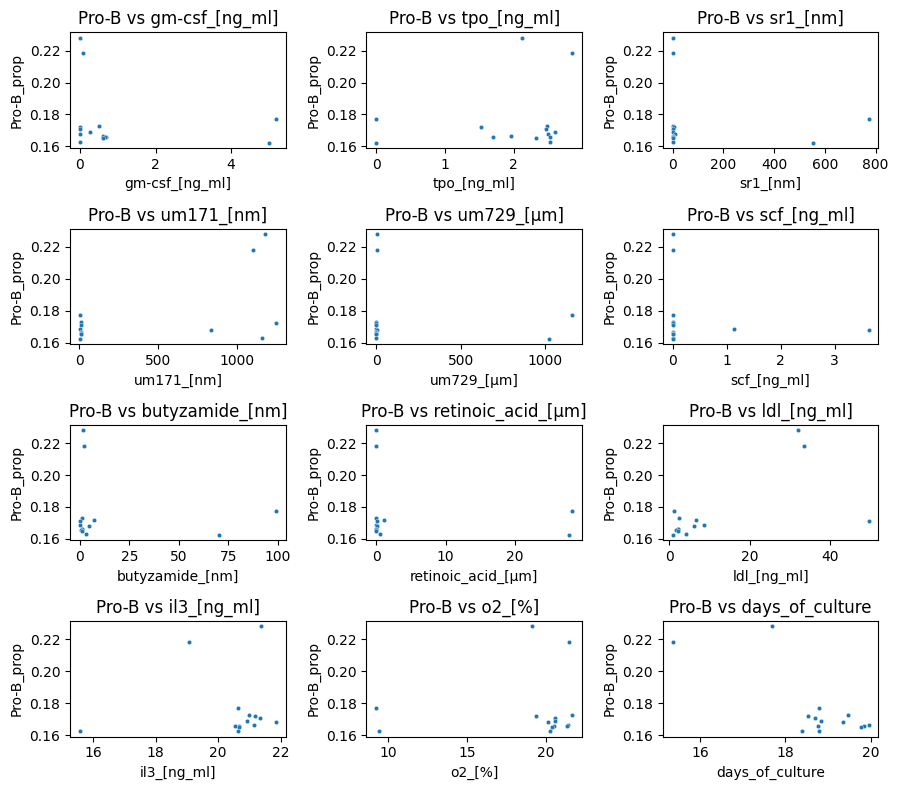

In [15]:
for cell_type in filtered_df:
    # Cell type safe
    cell_type_safe = cell_type.replace(":", "/")
    
    n_params = len(protocol_cols)
    ncols = 3  # adjust as you like
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2*nrows))
    axes = axes.flatten()  # make indexing easy

    for i, param in enumerate(protocol_cols):
        sns.scatterplot(
            data=filtered_df[cell_type],
            x=param,
            y=f"{cell_type_safe}_prop",
            ax=axes[i], 
            s=10
        )
        axes[i].set_title(f"{cell_type} vs {param}")

    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [16]:
bounds

{'gm-csf_[ng_ml]': (0.0, 10.0),
 'tpo_[ng_ml]': (0.0, 2.5),
 'um171_[nm]': (0.0, 1120.0),
 'um729_[µm]': (0.0, 1120.0),
 'sr1_[nm]': (0.0, 750.0),
 'scf_[ng_ml]': (0.0, 50.0),
 'butyzamide_[nm]': (0.0, 100.0),
 'retinoic_acid_[µm]': (0.0, 25.0),
 'ldl_[ng_ml]': (0.0, 50.0),
 'il3_[ng_ml]': (0.0, 20.0),
 'o2_[%]': (10.0, 20.0),
 'days_of_culture': (12.0, 18.0)}

## Focus on MgkPro and similarity with Sakurai 

In [17]:
path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge"

In [18]:
sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

In [19]:
dict(zip(protocol_cols, sakurai_medium))

{'gm-csf_[ng_ml]': np.int64(0),
 'tpo_[ng_ml]': np.int64(0),
 'sr1_[nm]': np.int64(0),
 'um171_[nm]': np.int64(70),
 'um729_[µm]': np.int64(0),
 'scf_[ng_ml]': np.int64(0),
 'butyzamide_[nm]': np.int64(100),
 'retinoic_acid_[µm]': np.int64(0),
 'ldl_[ng_ml]': np.int64(0),
 'il3_[ng_ml]': np.int64(0),
 'o2_[%]': np.int64(20),
 'days_of_culture': np.int64(14)}

In [20]:
MgkPro_df = filtered_df["MgkPro"]

In [21]:
dist_mgkpro_sakurai = np.abs(MgkPro_df.loc[:, protocol_cols].values - sakurai_medium[None, :]).sum(1)

In [22]:
np.argmin(dist_mgkpro_sakurai)

np.int64(997)

In [23]:
MgkPro_df.iloc[979]

gm-csf_[ng_ml]                                                                      0.81543
tpo_[ng_ml]                                                                        0.477664
sr1_[nm]                                                                          13.396067
um171_[nm]                                                                        410.17587
um729_[µm]                                                                         5.871619
scf_[ng_ml]                                                                             0.0
butyzamide_[nm]                                                                    37.32798
retinoic_acid_[µm]                                                                 0.835489
ldl_[ng_ml]                                                                             0.0
il3_[ng_ml]                                                                        9.765875
o2_[%]                                                                          

In [24]:
distances_from_sakurai_per_cell_type = {}

for cell_type in filtered_df:
    df_cell_type = filtered_df[cell_type]
    distances_from_sakurai_per_cell_type[cell_type] = np.abs(df_cell_type.loc[:, protocol_cols].values - sakurai_medium[None, :]).sum(1)

73.87241324000001


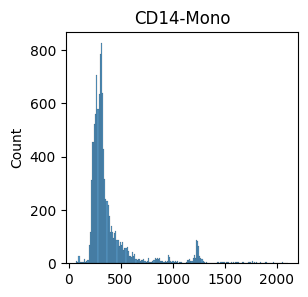

404.50443893000005


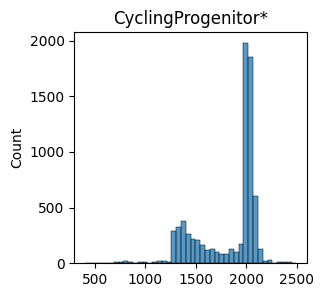

267.56477292115596


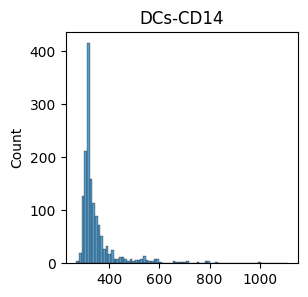

163.57174612


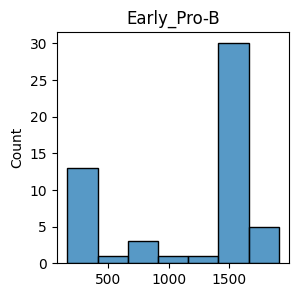

79.13640380349999


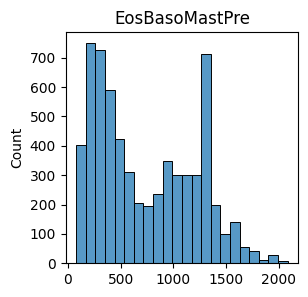

179.28297652999996


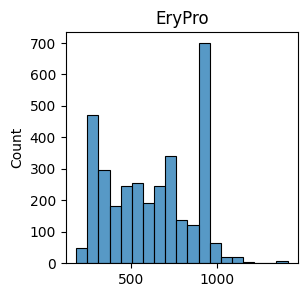

144.68513857


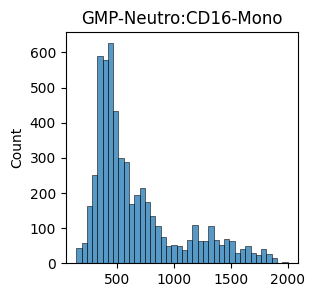

104.4845766734


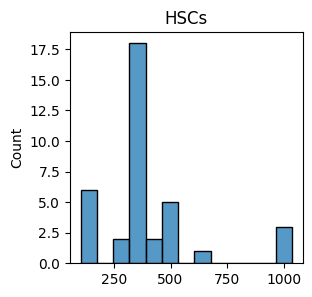

119.03860253599998


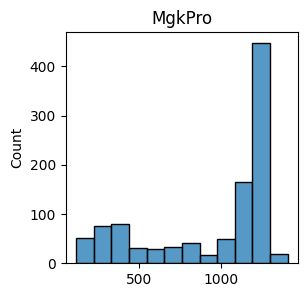

192.54778952


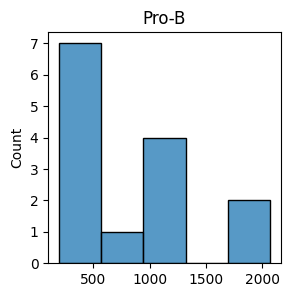

In [25]:
for cell_type in distances_from_sakurai_per_cell_type:
    plt.figure(figsize=(3,3))
    sns.histplot(distances_from_sakurai_per_cell_type[cell_type])
    print(np.min(distances_from_sakurai_per_cell_type[cell_type]))
    plt.title(cell_type)
    plt.show()

## Check uncertainties at every filtering step 

In [26]:
# def annotate_filtering_steps(): 

In [27]:
# for cell_type in pure_cell_type_solution_dict_concat:
#     cell_type_safe = cell_type.replace(":", "/")

#     df_plot = pure_cell_type_solution_dict_concat[cell_type].reset_index(drop=True)

#     plt.figure(figsize=(2,2))
#     sns.scatterplot(
#         data=df_plot,
#         x=f"{cell_type_safe}_prop",
#         y="target_ct_loss_std",
#         edgecolor="black"
#     )
#     plt.show()

## Compare uncertainty of solutions that make the cut 

In [28]:
# for cell_type in annotated_df:

#     df_plot = annotated_df[cell_type].reset_index(drop=True)

#     plt.figure(figsize=(2.8, 3.2))

#     ax = sns.boxplot(
#         data=df_plot,
#         x="filtering_step",
#         y="target_ct_loss_std",
#         hue="filtering_step", 
#         order=["proportion_filter", "oxygen_days", "bounds", "pass"],
#         width=0.6,
#         fliersize=1,
#         palette="colorblind"
#     )

#     # Clean aesthetics
#     sns.despine()
#     ax.set_xlabel("")
#     ax.set_ylabel("Target CT loss (std)")
#     ax.set_title(cell_type, fontsize=10)

#     plt.xticks(rotation=90, ha="right")
#     plt.tight_layout()
#     plt.show()

TODO:
* Compare with Sakurai
* Same analysis with custom (HSCs, MgkPro, EryPro)
* Uncertainty calibration 

In [29]:
annotated_df["Early_Pro-B"]["filtering_step"].value_counts()

filtering_step
bounds_days_of_culture       8875
proportion_filter            8835
oxygen_days                  7565
bounds_scf_[ng_ml]           4212
bounds_gm-csf_[ng_ml]        2852
bounds_um171_[nm]            1819
bounds_tpo_[ng_ml]           1141
bounds_sr1_[nm]              1036
bounds_o2_[%]                 939
bounds_butyzamide_[nm]        486
bounds_il3_[ng_ml]            214
pass                           54
bounds_ldl_[ng_ml]             48
bounds_um729_[µm]              23
bounds_retinoic_acid_[µm]       1
Name: count, dtype: int64

In [30]:
annotated_df["HSCs"]["filtering_step"].value_counts()

filtering_step
oxygen_days                  6243
proportion_filter            5236
bounds_days_of_culture       5230
bounds_scf_[ng_ml]           2021
bounds_um171_[nm]            1407
bounds_o2_[%]                1064
bounds_gm-csf_[ng_ml]         651
bounds_sr1_[nm]               540
bounds_tpo_[ng_ml]            443
bounds_il3_[ng_ml]            145
bounds_butyzamide_[nm]        132
bounds_ldl_[ng_ml]             44
pass                           37
bounds_um729_[µm]               5
bounds_retinoic_acid_[µm]       2
Name: count, dtype: int64

In [31]:
annotated_df["Early_Pro-B"].max(0)

gm-csf_[ng_ml]                                                                  4730.371
tpo_[ng_ml]                                                                      71021.4
sr1_[nm]                                                               244782110000000.0
um171_[nm]                                                                   662204350.0
um729_[µm]                                                                 11397916000.0
scf_[ng_ml]                                                                41133560000.0
butyzamide_[nm]                                                               17149444.0
retinoic_acid_[µm]                                                              50.57831
ldl_[ng_ml]                                                                    1028.4215
il3_[ng_ml]                                                                    5468.6445
o2_[%]                                                                         1540.3678
days_of_culture      

In [32]:
bounds

{'gm-csf_[ng_ml]': (0.0, 10.0),
 'tpo_[ng_ml]': (0.0, 2.5),
 'um171_[nm]': (0.0, 1120.0),
 'um729_[µm]': (0.0, 1120.0),
 'sr1_[nm]': (0.0, 750.0),
 'scf_[ng_ml]': (0.0, 50.0),
 'butyzamide_[nm]': (0.0, 100.0),
 'retinoic_acid_[µm]': (0.0, 25.0),
 'ldl_[ng_ml]': (0.0, 50.0),
 'il3_[ng_ml]': (0.0, 20.0),
 'o2_[%]': (10.0, 20.0),
 'days_of_culture': (12.0, 18.0)}

In [33]:
for t_warmup, vmin, vmax in zip(filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 1.0
t_warmup: 0.1 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 1.0
t_warmup: 0.0 vmin: 10.0 vm

In [34]:
for t_warmup, vmin, vmax in zip(filtered_df["HSCs"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["HSCs"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.1 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 15.0 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.0 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.0 vmin: 15.0 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 2.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.25 vmin: 10.0 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 1.0
t_warmup: 0.25 vmin: 

In [35]:
for t_warmup, vmin, vmax in zip(filtered_df["Pro-B"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.0 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 2.0
t_warmup: 0.0 vmin: 10.0 vmax: 2.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 1.0


In [36]:
for t_warmup, vmin, vmax in zip(filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
    print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.1 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.0 vmin: 10.0 vmax: 5.0
t_warmup: 0.1 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 15.0 vmax: 1.0
t_warmup: 0.0 vmin: 15.0 vmax: 5.0
t_warmup: 0.0 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 1.0
t_warmup: 0.0 vmin: 15.0 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 2.0
t_warmup: 0.1 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 7.5 vmax: 1.0
t_warmup: 0.5 vmin: 7.5 vmax: 1.0
t_warmup: 0.1 vmin: 10.0 vmax: 1.0
t_warmup: 0.25 vmin: 15.0 vmax: 5.0
t_warmup: 0.1 vmin: 10.0 vmax: 5.0
t_warmup: 0.25 vmin: 10.0 vmax: 1.0
t_warmup: 0.1 vmin: 10.0 vmax: 2.0
t_warmup: 0.0 vmin: 15.0 vmax: 2.0
t_warmup: 0.0 vmin: 10.0 vmax: 2.0
t_warmup: 0.25 vmin: 7.5 vmax: 5.0
t_warmup: 0.0 vmin: 7.5 vmax: 2.0
t_warmup: 0.5 vmin: 15.0 vmax: 2.0
t_warmup: 0.1 vmin: 15.0 vmax: 5.0
t_warmup: 0.5 vmin: 10.0 vmax: 5.0
t_warmup: 0.5 vmin: 7.5 vmax: 5.0
t_warmup: 0.5 vmin:

In [37]:
filtered_df["EryPro"]["run_name"].value_counts()

run_name
penalized_all_axes-pure_populations-constant      2123
penalized_all_axes-pure_populations-reciprocal     717
penalized_oxy_days-pure_populations-constant       303
penalized_oxy_days-pure_populations-reciprocal     187
unconstrained-pure_populations-reciprocal           10
unconstrained-pure_populations-constant              7
Name: count, dtype: int64

In [38]:
filtered_df["EryPro"][filtered_df["EryPro"]["EryPro_prop"]>0.40].loc[:, protocol_cols]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
95,2.811382,0.0,101.41675,0.086865,0.00538,0.0,22.873796,0.019207,0.0,0.886919,22.784748,19.671104
95,2.537652,0.0,91.03853,0.305333,0.00000,0.0,22.148872,0.000000,0.0,0.940211,22.934235,18.980879


## Check values of penalization parameters

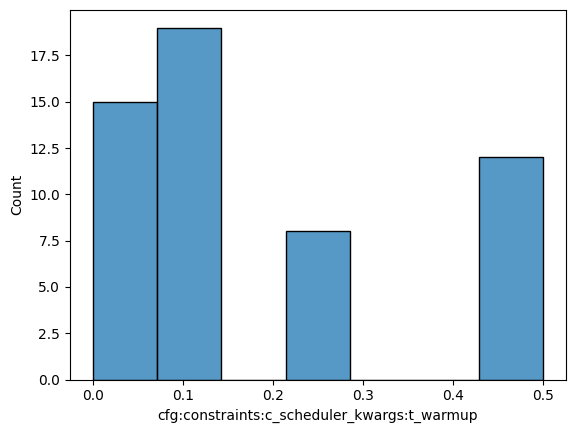

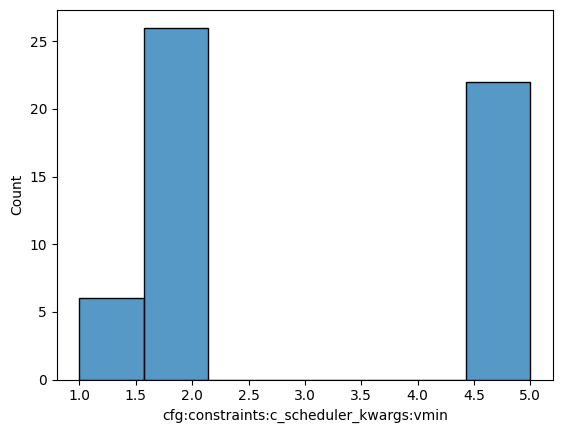

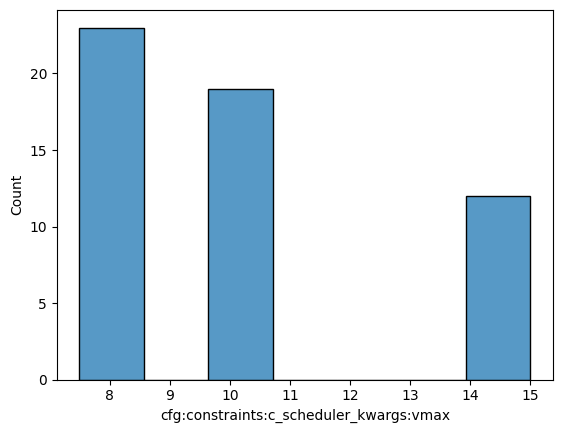

In [47]:
sns.histplot(data=filtered_df["Early_Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:t_warmup")
plt.show()

sns.histplot(data=filtered_df["Early_Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmin")
plt.show()

sns.histplot(data=filtered_df["Early_Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmax")
plt.show()

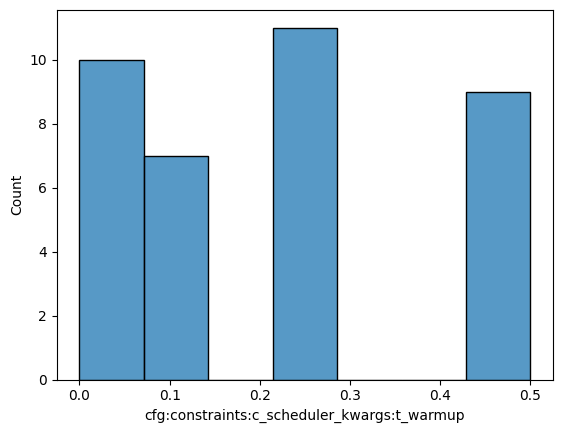

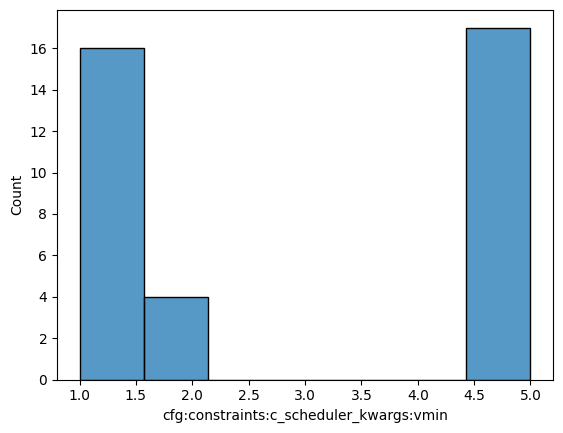

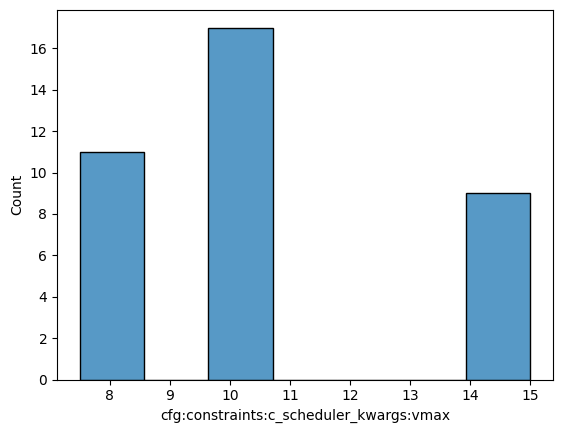

In [48]:
sns.histplot(data=filtered_df["HSCs"],
             x="cfg:constraints:c_scheduler_kwargs:t_warmup")
plt.show()

sns.histplot(data=filtered_df["HSCs"],
             x="cfg:constraints:c_scheduler_kwargs:vmin")
plt.show()

sns.histplot(data=filtered_df["HSCs"],
             x="cfg:constraints:c_scheduler_kwargs:vmax")
plt.show()

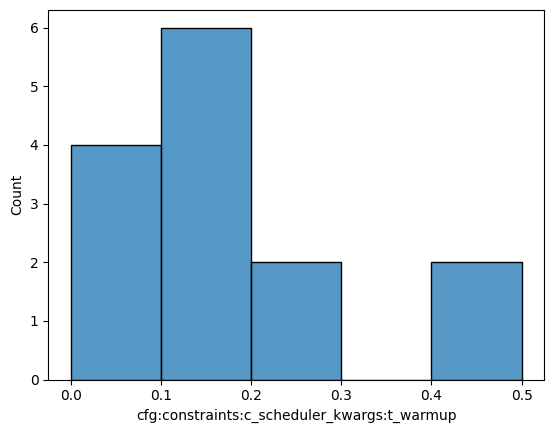

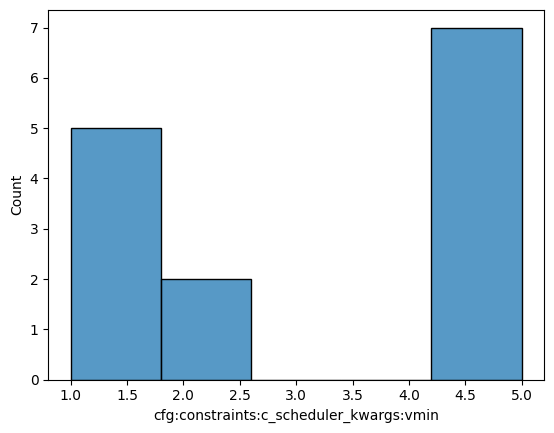

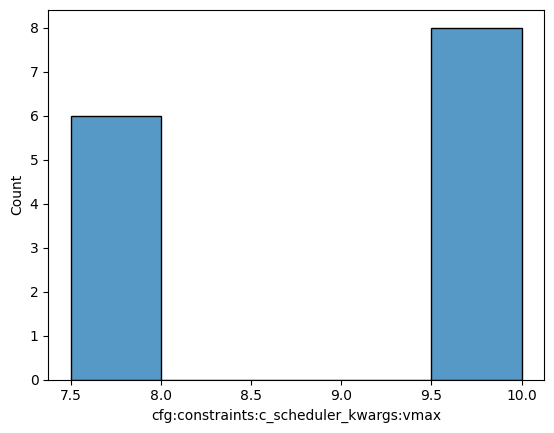

In [50]:
sns.histplot(data=filtered_df["Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:t_warmup")
plt.show()

sns.histplot(data=filtered_df["Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmin")
plt.show()

sns.histplot(data=filtered_df["Pro-B"],
             x="cfg:constraints:c_scheduler_kwargs:vmax")
plt.show()